In [2]:
import pandas as pd
df_clean = pd.read_csv("online_retail_enriched.csv")

In [3]:
monthly_revenue = df_clean.groupby(['OrderYear','OrderMonth'])['Revenue'].sum().reset_index()
monthly_revenue

,OrderYear,OrderMonth,Revenue
0,2009,12,683504.010
1,2010,1,555802.672
2,2010,2,504558.956
3,2010,3,696978.471
4,2010,4,591982.002
5,2010,5,597833.380
6,2010,6,636371.130
7,2010,7,589736.170
8,2010,8,602224.600
9,2010,9,829013.951


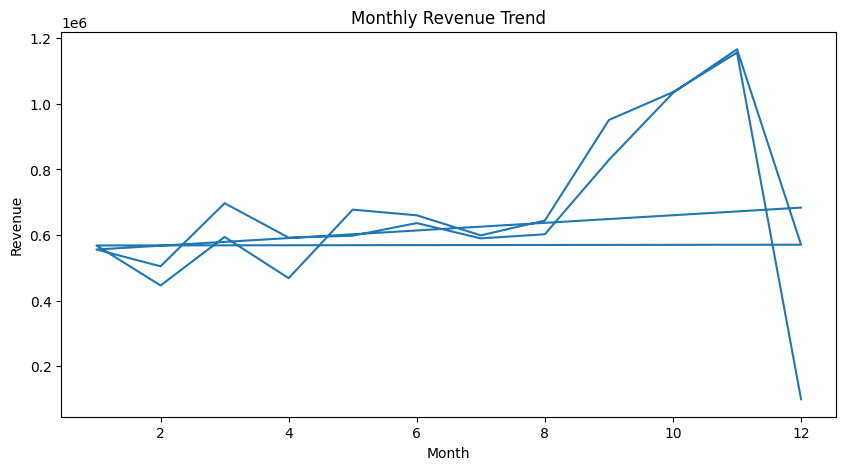

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['OrderMonth'], monthly_revenue['Revenue'])
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.show()


In [5]:
# Revenue shows strong seasonality with peak sales in November and December, likely driven by holiday shopping and promotions.

# Top Countries by Revenue

In [6]:
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries

Country
United Kingdom    1.400996e+07
EIRE              6.102686e+05
Netherlands       5.423101e+05
Germany           4.177984e+05
France            3.439847e+05
Australia         1.692835e+05
Spain             1.080163e+05
Switzerland       1.000619e+05
Sweden            9.127782e+04
Denmark           6.841179e+04
Name: Revenue, dtype: float64

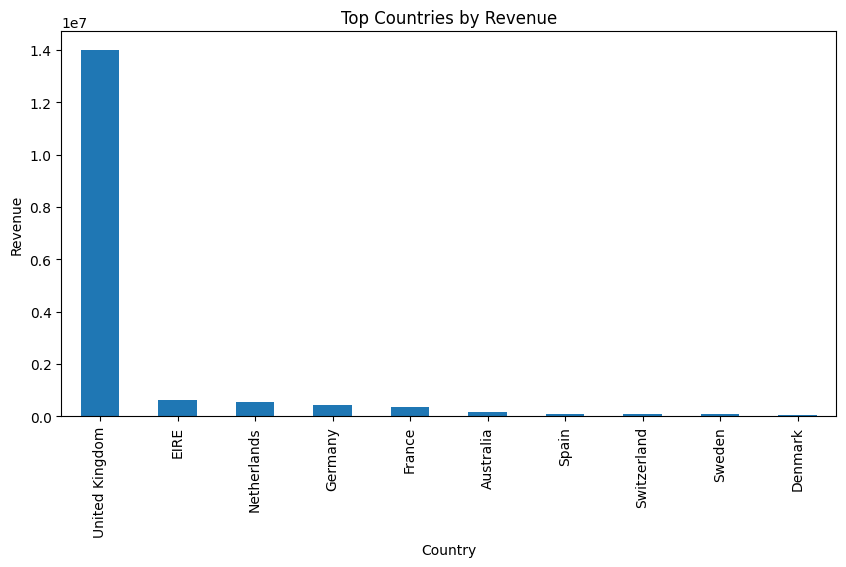

In [7]:
top_countries.plot(kind='bar', figsize=(10,5))
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

In [8]:
# United Kingdom contributes the majority of revenue, followed by several European countries such as Germany and France.

# Top Products (Categories)

In [9]:
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              273694.42
WHITE HANGING HEART T-LIGHT HOLDER    245488.77
Manual                                151350.21
JUMBO BAG RED RETROSPOT               133467.00
ASSORTED COLOUR BIRD ORNAMENT         123330.16
POSTAGE                               122527.04
PARTY BUNTING                         103030.93
MEDIUM CERAMIC TOP STORAGE JAR         81243.22
PAPER CHAIN KIT 50'S CHRISTMAS         73913.76
CHILLI LIGHTS                          67855.98
Name: Revenue, dtype: float64

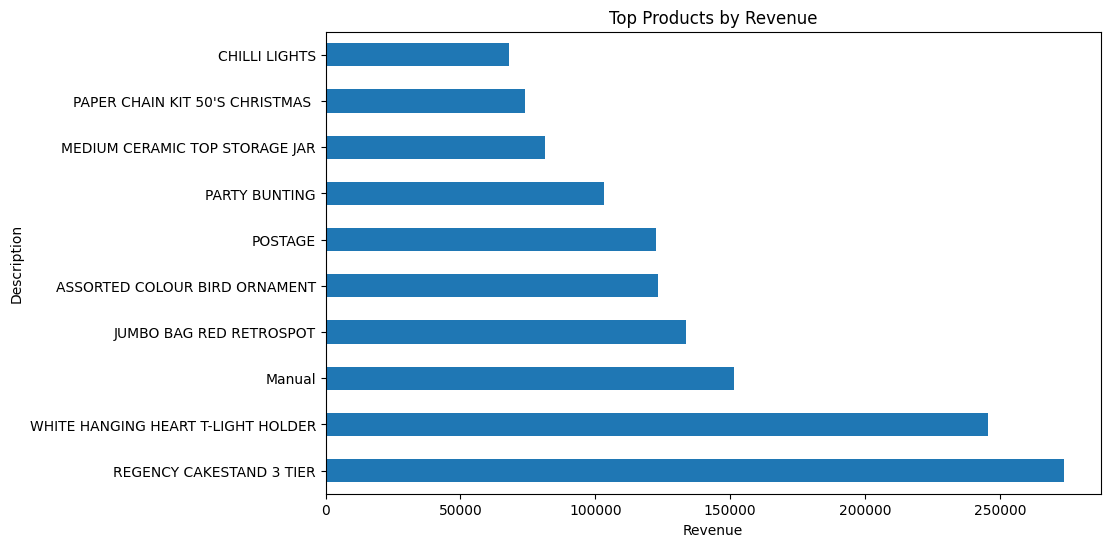

In [10]:
top_products.plot(kind='barh', figsize=(10,6))
plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.show()

In [11]:
# Decorative household items and gift products dominate the top-selling product list.

# Average Order Value (AOV)

In [12]:
# AOV = Total Revenue / Total Order

In [14]:
order_revenue = df_clean.groupby('Invoice')['Revenue'].sum()
# The average order value indicates the typical customer spending per transaction.

# Repeat Purchase Rate

In [16]:
orders_per_customer = df_clean.groupby('Customer ID')['Invoice'].nunique()

In [17]:
repeat_customers = orders_per_customer[orders_per_customer > 1]

In [18]:
repeat_rate = len(repeat_customers) / len(orders_per_customer)
repeat_rate

0.7199385979873785

<Axes: ylabel='Revenue'>

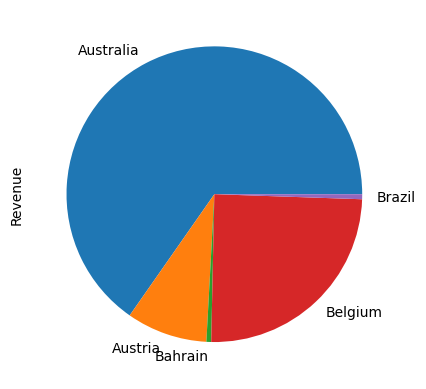

In [20]:
df_clean.groupby('Country')['Revenue'].sum().head(5).plot(kind='pie')